# Session 13 — second seed: is leapfrog really better than the baseline?

In the main notebook ([`S13.ipynb`](S13.ipynb)), reversible **leapfrog** finished at a lower
validation loss than the ordinary baseline at the same batch, tokens and schedule. So did
midpoint. But that was **one run per arm**, and a gap of a few hundredths of a nat is the size
a different random seed can produce by itself.

This notebook repeats the two arms that matter, baseline and leapfrog, with a **new seed for
both the initial weights and the data order**. Both arms share the new seed, so each seed is a
paired comparison: same starting randomness, same batches, only the residual rule differs.
Changing the data order as well as the init is deliberately the harder test. A gap that
survives both kinds of reshuffle is not a quirk of one particular ordering.

**Nothing is re-implemented here.** The data, model and training-loop cells are executed
verbatim from [`notebook_src.py`](notebook_src.py), the source of the main notebook, so the
model and loop are the same code that produced the main results. The main notebook's gates
are not rerun. The batch size and every other setting are read back from the main run's
`results.json`, and this notebook's results are added to that same file under `seeds`.

In [1]:
import json, pathlib, re, time
import numpy as np

SRC = pathlib.Path("notebook_src.py").read_text()
CELLS = [c for c in re.split(r"^# %%.*$", SRC, flags=re.M) if c.strip()]

def cell_with(marker):
    hits = [c for c in CELLS if marker in c]
    assert len(hits) == 1, (marker, len(hits))
    return hits[0]

# the cells this comparison needs, in notebook order — environment, data, model, training loop
NEEDED = ["T_START = time.perf_counter()", "def fetch(", "TOK_PATH = pathlib.Path",
          "def encode_to(", "N_WIN = (len(train_ids) - 1) // SEQ", "class RevStack(",
          "def train(name, rule, B"]
for marker in NEEDED:
    exec(cell_with(marker), globals())

MAIN = json.loads(pathlib.Path("results.json").read_text())
B_FIXED = MAIN["batch"]["fixed"]
assert SMOKE or (MAIN["model"]["params"] == N_PARAMS and MAIN["data"]["seq_len"] == SEQ)
print(f"\nre-using the main run's settings: batch {B_FIXED}, {N_PARAMS:,} parameters, "
      f"{TRAIN_TOKENS:,} tokens, lr {LR}")

{
  "device": "cuda",
  "torch": "2.5.1+cu121",
  "smoke": false,
  "python": "3.10.12",
  "gpu": "Tesla T4",
  "gpu_mem_gib": 14.56,
  "sm": "75"
}

This card has no bfloat16 (sm_75). Every run below uses float16 autocast with a GradScaler, and keeps the residual stream itself in float32.


293,029 training stories, 27,629 validation stories
vocab 8192  sample: ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġa', 'Ġlittle', 'Ġdog']


encoded in 3s: 55.23M train tokens, 5.42M validation tokens


parameters: 21.18M total (tied embeddings), 18.95M in the transformer blocks, 2.10M token embedding, 0.13M positions

re-using the main run's settings: batch 72, 21,182,976 parameters, 50,000,000 tokens, lr 0.001


## The seeds

Seed 1 is the main notebook's run, read back from `results.json` rather than repeated:
init seed 1234, data order seed 1337. Seed 2 is new: init seed 2025, data order seed 2026.
The data order is the shuffle of the 512-token training windows. Both arms still see exactly
the same 50M tokens, in a different order.

In [2]:
SEED2 = {"init": 2025, "order": 2026}
WIN_ORDER = np.random.default_rng(SEED2["order"]).permutation(N_WIN)   # get_batch() reads this

SEED_RUNS = {}
SEED_RUNS["baseline"] = train("baseline_seed2", "standard", B_FIXED, seed=SEED2["init"], keep_model=False)

  baseline_seed2         step     1/1357  train 9.046  val 8.716  lr 2.50e-05


  baseline_seed2         step   151/1357  train 3.684  val 3.638  lr 9.85e-04


  baseline_seed2         step   302/1357  train 2.993  val 2.924  lr 9.16e-04


  baseline_seed2         step   453/1357  train 2.589  val 2.519  lr 8.00e-04


  baseline_seed2         step   603/1357  train 2.357  val 2.266  lr 6.53e-04


...

  baseline_seed2         step   905/1357  train 2.013  val 1.992  lr 3.38e-04


  baseline_seed2         step  1055/1357  train 1.945  val 1.915  lr 2.13e-04


  baseline_seed2         step  1206/1357  train 1.863  val 1.865  lr 1.29e-04


  baseline_seed2         step  1357/1357  train 1.879  val 1.833  lr 1.00e-04


  → baseline_seed2: val 1.8332, 59.3K tok/s, peak 11.34 GiB, 14.6 min


In [3]:
SEED_RUNS["leapfrog"] = train("leapfrog_seed2", "leapfrog", B_FIXED, seed=SEED2["init"], keep_model=False)

  leapfrog_seed2         step     1/1357  train 9.036  val 8.810  lr 2.50e-05


  leapfrog_seed2         step   151/1357  train 3.364  val 3.325  lr 9.85e-04


  leapfrog_seed2         step   302/1357  train 2.711  val 2.636  lr 9.16e-04


  leapfrog_seed2         step   453/1357  train 2.373  val 2.306  lr 8.00e-04


  leapfrog_seed2         step   603/1357  train 2.186  val 2.109  lr 6.53e-04


...

  leapfrog_seed2         step   905/1357  train 1.916  val 1.892  lr 3.38e-04


  leapfrog_seed2         step  1055/1357  train 1.859  val 1.828  lr 2.13e-04


  leapfrog_seed2         step  1206/1357  train 1.780  val 1.785  lr 1.29e-04


  leapfrog_seed2         step  1357/1357  train 1.801  val 1.760  lr 1.00e-04


  → leapfrog_seed2: val 1.7603, 34.8K tok/s, peak 3.72 GiB, 24.5 min


## Paired comparison

In [4]:
m = MAIN["runs"]
pairs = {
    "seed 1 (main run)": (m["baseline"]["final_val_loss"], m["rev_leapfrog"]["final_val_loss"]),
    "seed 2": (SEED_RUNS["baseline"]["final_val_loss"], SEED_RUNS["leapfrog"]["final_val_loss"]),
}
print(f"{'':18s} {'baseline':>9s} {'leapfrog':>9s} {'leapfrog − baseline':>20s}")
for k, (b, l) in pairs.items():
    print(f"{k:18s} {b:9.4f} {l:9.4f} {l - b:+20.4f}")

deltas = [l - b for b, l in pairs.values()]
base_spread = abs(pairs["seed 2"][0] - pairs["seed 1 (main run)"][0])
leap_spread = abs(pairs["seed 2"][1] - pairs["seed 1 (main run)"][1])
print(f"\nseed-to-seed change in the baseline alone: {base_spread:.4f}")
print(f"seed-to-seed change in leapfrog alone:     {leap_spread:.4f}")
print(f"leapfrog − baseline, per seed:           {deltas[0]:+.4f}, {deltas[1]:+.4f}")

# the gap at every evaluation, not only the last one
ev_b = SEED_RUNS["baseline"]["evals"]["val_loss"]; ev_l = SEED_RUNS["leapfrog"]["evals"]["val_loss"]
gaps2 = [l - b for b, l in zip(ev_b, ev_l)]
gaps1 = [l - b for b, l in zip(MAIN["curves"]["baseline"]["evals"]["val_loss"],
                                MAIN["curves"]["rev_leapfrog"]["evals"]["val_loss"])]
print("\ngap at each of the 10 evaluations (leapfrog − baseline):")
print("  seed 1:", " ".join(f"{g:+.3f}" for g in gaps1))
print("  seed 2:", " ".join(f"{g:+.3f}" for g in gaps2))
same_sign = all(d < 0 for d in deltas)
print(f"\nleapfrog lower than baseline in both seeds: {same_sign}")

                    baseline  leapfrog  leapfrog − baseline
seed 1 (main run)     1.8289    1.7664              -0.0625
seed 2                1.8332    1.7603              -0.0729

seed-to-seed change in the baseline alone: 0.0043
seed-to-seed change in leapfrog alone:     0.0061
leapfrog − baseline, per seed:           -0.0625, -0.0729

gap at each of the 10 evaluations (leapfrog − baseline):
  seed 1: +0.117 -0.328 -0.259 -0.173 -0.126 -0.104 -0.084 -0.075 -0.067 -0.063
  seed 2: +0.095 -0.314 -0.288 -0.213 -0.158 -0.119 -0.100 -0.087 -0.081 -0.073

leapfrog lower than baseline in both seeds: True


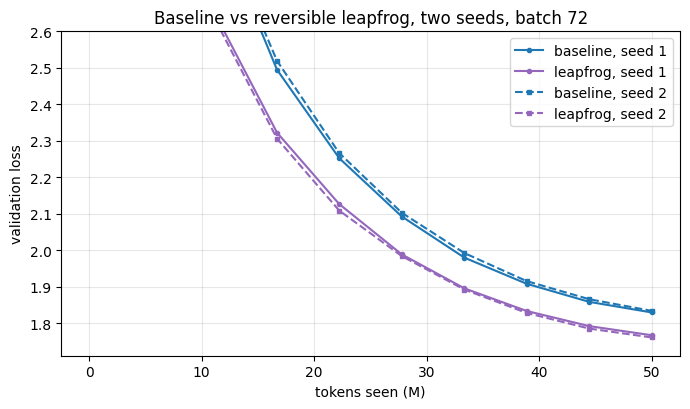

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(7, 4.2))
tok = np.array(MAIN["curves"]["baseline"]["evals"]["tokens"]) / 1e6
ax.plot(tok, MAIN["curves"]["baseline"]["evals"]["val_loss"], "o-", c="C0", ms=3, label="baseline, seed 1")
ax.plot(tok, MAIN["curves"]["rev_leapfrog"]["evals"]["val_loss"], "o-", c="C4", ms=3, label="leapfrog, seed 1")
tok2 = np.array(SEED_RUNS["baseline"]["evals"]["tokens"]) / 1e6
ax.plot(tok2, ev_b, "s--", c="C0", ms=3, label="baseline, seed 2")
ax.plot(tok2, ev_l, "s--", c="C4", ms=3, label="leapfrog, seed 2")
ax.set_ylim(min(ev_l + ev_b) - 0.05, 2.6)
ax.set_xlabel("tokens seen (M)"); ax.set_ylabel("validation loss")
ax.set_title(f"Baseline vs reversible leapfrog, two seeds, batch {B_FIXED}")
ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig("assets/seeds_leapfrog_vs_baseline.png", dpi=120); plt.show()

## Write results

Added to the main run's `results.json` under `seeds`. The main notebook writes that file from
scratch, so if it is ever rerun, this notebook must be rerun after it.

In [6]:
def slim(r):
    return {k: v for k, v in r.items() if k not in ("log", "evals")}
MAIN["seeds"] = {
    "seed2": {"init": SEED2["init"], "order": SEED2["order"],
              "baseline": slim(SEED_RUNS["baseline"]), "leapfrog": slim(SEED_RUNS["leapfrog"]),
              "delta": deltas[1], "gaps": gaps2},
    "seed1": {"init": 1234, "order": 1337, "delta": deltas[0], "gaps": gaps1},
    "baseline_spread": base_spread, "leapfrog_spread": leap_spread,
    "mean_delta": float(np.mean(deltas)), "both_lower": same_sign,
    "runtime_min": (time.perf_counter() - T_START) / 60,
}
pathlib.Path("results.json").write_text(json.dumps(MAIN, indent=2, default=float))
print("===RESULTS-JSON-BEGIN===")
print(json.dumps(MAIN["seeds"], default=float))
print("===RESULTS-JSON-END===")
print(f"seed notebook runtime {MAIN['seeds']['runtime_min']:.1f} min")

===RESULTS-JSON-BEGIN===
{"seed2": {"init": 2025, "order": 2026, "baseline": {"name": "baseline_seed2", "rule": "standard", "batch": 72, "lr": 0.001, "steps": 1357, "tokens_trained": 50024448, "final_val_loss": 1.8332179076969624, "final_train_loss": 1.8487118126741096, "tokens_per_s": 59297.46851901791, "wall_s": 874.260044674, "wall_min": 14.571000744566668, "cost_usd": 0.20107981027502, "finite": true, "peak_alloc_gib": 11.340500354766846, "peak_reserved_gib": 11.986328125}, "leapfrog": {"name": "leapfrog_seed2", "rule": "leapfrog", "batch": 72, "lr": 0.001, "steps": 1357, "tokens_trained": 50024448, "final_val_loss": 1.760275911539793, "final_train_loss": 1.7730307507870802, "tokens_per_s": 34770.40259463634, "wall_s": 1472.0650973680001, "wall_min": 24.534418289466668, "cost_usd": 0.33857497239464, "finite": true, "peak_alloc_gib": 3.7203831672668457, "peak_reserved_gib": 4.470703125}, "delta": -0.07294199615716934, "gaps": [0.0946265459060669, -0.31366725265979767, -0.28784847259